## Career Intelligence & Skills Evolution Analyzer
#### 01_eda_and_preprocessing.ipynb

#### Objective
This notebook performs:
- Data loading and schema inspection
- Raw data quality audit
- Before-cleaning EDA visualizations
- Salary, experience, and text cleaning
- Skill extraction from job descriptions
- Student profile preparation
- Automation risk labeling
- After-cleaning validation and exports

#### Datasets
- `tech_jobs_data.csv`
- `job_market.csv`
- `student_data.xlsx`

Import Libraries & Setup

In [4]:
import warnings
warnings.filterwarnings("ignore")

import re
import ast
import json
import math
import string
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer

In [5]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 200)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_STATE = 42
DATA_DIR = Path("../data/raw")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

#### 1. Load Datasets
We start by loading all raw files and inspecting shape, columns, sample rows, data types, missing values, and duplicates.

In [6]:
tech_jobs = pd.read_csv(DATA_DIR / "tech_jobs_data.csv")
job_market = pd.read_csv(DATA_DIR / "job_market.csv")
students = pd.read_excel(DATA_DIR / "student_data.xlsx")

In [7]:
datasets = {
    "tech_jobs": tech_jobs,
    "job_market": job_market,
    "students": students
}

for name, df in datasets.items():
    print("=" * 80)
    print(f"{name.upper()} SHAPE: {df.shape}")
    print("COLUMNS:", list(df.columns))
    print("\nINFO:")
    print(df.info())
    print("\nMISSING VALUES:")
    print(df.isnull().sum().sort_values(ascending=False).head(10))
    print("\nDUPLICATES:", df.duplicated().sum())
    print("\nHEAD:")
    display(df.head(3))

TECH_JOBS SHAPE: (5466, 7)
COLUMNS: ['company', 'category', 'post_link', 'job_description', 'location', 'date_posted', 'keywords']

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5466 entries, 0 to 5465
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   company          5454 non-null   object
 1   category         5466 non-null   object
 2   post_link        5466 non-null   object
 3   job_description  5466 non-null   object
 4   location         5324 non-null   object
 5   date_posted      5466 non-null   object
 6   keywords         5465 non-null   object
dtypes: object(7)
memory usage: 299.1+ KB
None

MISSING VALUES:
location           142
company             12
keywords             1
post_link            0
category             0
job_description      0
date_posted          0
dtype: int64

DUPLICATES: 0

HEAD:


,company,category,post_link,job_description,location,date_posted,keywords
0,Oowlish Technology,Data,https://jobs.lever.co/oowlish/d6eecb01-20fd-4cad-9645-35bece0c826f,"Oowlish Technology - Founding Engineer - AI/Python Cookie Policy 🍪 Deny Accept Privacy Notice This website uses cookies to improve your web experience. By clicking Accept , you agree to the use of...",Remote,2024-10-27,"Python,AWS,Langchain,LlamaIndex,GitHub Copilot,Codium,Web automation,web scraping,Shopify"
1,Oneida ESC Group,Other,https://www.indeed.com/rc/clk?jk=d50cb8217a9d0999&bb=Hf7D4gSlfXN9RPZghKuiOOzltyjOuRxU8P9aDh1UFJ_Z3DMm8AQYRFjZguvLhuTmEKxxvnPyI_FyHojud2dP_wYX-r9jD1g3BeWZXz10koCJjN6OWgtC9CzoHO3qdM02&xkcb=SoDX67M36...,"Oneida Total Integrated Enterprises (OTIE) currently has an immediate opening for a Remote Senior Structural Engineer. We currently have a solid backlog of projects, an excellent staff of engineer...",Remote,2024-10-27,"RAM, Tedds, Adapt, Revit, AutoCad, MS Word, Excel, concrete, steel, wood, CMU, structural analysis, NCEES, post-tension, condition assessment"
2,Affinity Psychological Services. P.C.,Management,https://www.indeed.com/rc/clk?jk=586bc232758c63db&bb=qYTQNFIzGeVTlzDLTbTgLab-_N0t-BANdWsghSagBR0L98hh6rktxxTXswSu2m_pZ0OmOlHG9bOnGsfYbJQlrWUDKM4JcZ3IkIahyHLTAYULXQleXWxI5wSVQRiBQzyc&xkcb=SoD467M36...,Affinity Psychological Services is a rapidly-growing mental health group private practice that is diversity-affirming and committed to anti-burnout culture in everything we do. We nurture and cele...,Remote,2024-10-27,"SimplePractice, EHR, HIPAA, CPT, ICD-10, SQL (implied by reporting), Excel (implied by financial reports)"


JOB_MARKET SHAPE: (5000, 16)
COLUMNS: ['User_ID', 'Country', 'Current_Role', 'Kaggle_Tier', 'Years_Experience', 'Hours_Spent_Weekly', 'Gold_Medals', 'Silver_Medals', 'Datasets_Shared', 'Competitions_Entered', 'Follower_Count', 'Github_Link', 'Portfolio_Score', 'Total_Certifications', 'Monthly_Recruiter_Pings', 'Salary_USD']

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   User_ID                  5000 non-null   object
 1   Country                  5000 non-null   object
 2   Current_Role             5000 non-null   object
 3   Kaggle_Tier              5000 non-null   object
 4   Years_Experience         5000 non-null   int64 
 5   Hours_Spent_Weekly       5000 non-null   int64 
 6   Gold_Medals              5000 non-null   int64 
 7   Silver_Medals            5000 non-null   int64 
 8   Datasets_Shared          

,User_ID,Country,Current_Role,Kaggle_Tier,Years_Experience,Hours_Spent_Weekly,Gold_Medals,Silver_Medals,Datasets_Shared,Competitions_Entered,Follower_Count,Github_Link,Portfolio_Score,Total_Certifications,Monthly_Recruiter_Pings,Salary_USD
0,KAG_2026_10000,India,Researcher,Expert,11,30,2,3,16,26,237,1,57,6,12,101507
1,KAG_2026_10001,USA,Data Scientist,Contributor,4,18,0,6,6,16,200,1,25,9,5,142205
2,KAG_2026_10002,India,Student,Contributor,2,10,0,3,11,20,170,1,26,2,4,0


STUDENTS SHAPE: (3600, 21)
COLUMNS: ['Sr.No.', 'Course', 'Job profession', 'Student', 'Linguistic', 'Musical', 'Bodily', 'Logical - Mathematical', 'Spatial-Visualization', 'Interpersonal', 'Intrapersonal', 'Naturalist', 's/p', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8']

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sr.No.                  72 non-null     float64
 1   Course                  0 non-null      float64
 2   Job profession          3600 non-null   object 
 3   Student                 3600 non-null   object 
 4   Linguistic              3600 non-null   int64  
 5   Musical                 3600 non-null   int64  
 6   Bodily                  3600 non-null   int64  
 7   Logical - Mathematical  3600 non-null   int64  
 8   Spatial-Visualization   3600 non-null   int64  
 9   Interpersonal          

,Sr.No.,Course,Job profession,Student,Linguistic,Musical,Bodily,Logical - Mathematical,Spatial-Visualization,Interpersonal,Intrapersonal,Naturalist,s/p,P1,P2,P3,P4,P5,P6,P7,P8
0,1.0,NaN,Astronomer\n,S1,11,5,12,16,17,11,18,19,s1,AVG,POOR,AVG,BEST,BEST,AVG,BEST,BEST
1,NaN,NaN,Astronomer\n,S2,12,6,12,16,16,11,18,19,s2,AVG,POOR,AVG,BEST,BEST,AVG,BEST,BEST
2,NaN,NaN,Astronomer\n,S3,13,7,12,16,15,11,18,19,s3,AVG,POOR,AVG,BEST,BEST,AVG,BEST,BEST


#### 2. Utility Functions
These helper functions standardize column names, clean salary and experience fields, clean text, and parse skills safely.

In [8]:
def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[\/\-\.\(\)]", "_", regex=True)
        .str.replace(r"\s+", "_", regex=True)
        .str.replace(r"__+", "_", regex=True)
        .str.strip("_")
    )
    return df

def parse_salary(value):
    if pd.isna(value):
        return np.nan
    value = str(value).lower().replace(",", "").replace("$", "").strip()
    nums = re.findall(r"\d+\.?\d*", value)
    if len(nums) == 0:
        return np.nan
    nums = [float(x) for x in nums]
    if len(nums) == 1:
        return nums[0]
    return np.mean(nums[:2])

def parse_experience(value):
    if pd.isna(value):
        return np.nan
    value = str(value).lower().strip()
    nums = re.findall(r"\d+\.?\d*", value)
    if len(nums) == 0:
        return np.nan
    nums = [float(x) for x in nums]
    if len(nums) == 1:
        return nums[0]
    return np.mean(nums[:2])

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z0-9\+\#\.\-/ ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def safe_literal_eval(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    try:
        value = ast.literal_eval(str(x))
        if isinstance(value, list):
            return value
        return [str(value)]
    except:
        return []

def clip_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series.clip(lower, upper)

#### 3. Standardize Schemas
Convert all datasets to consistent snake_case column names.

In [9]:
tech_jobs = clean_column_names(tech_jobs)
job_market = clean_column_names(job_market)
students = clean_column_names(students)

print("TECH JOBS COLUMNS:", tech_jobs.columns.tolist())
print("JOB MARKET COLUMNS:", job_market.columns.tolist())
print("STUDENTS COLUMNS:", students.columns.tolist())

TECH JOBS COLUMNS: ['company', 'category', 'post_link', 'job_description', 'location', 'date_posted', 'keywords']
JOB MARKET COLUMNS: ['user_id', 'country', 'current_role', 'kaggle_tier', 'years_experience', 'hours_spent_weekly', 'gold_medals', 'silver_medals', 'datasets_shared', 'competitions_entered', 'follower_count', 'github_link', 'portfolio_score', 'total_certifications', 'monthly_recruiter_pings', 'salary_usd']
STUDENTS COLUMNS: ['sr_no', 'course', 'job_profession', 'student', 'linguistic', 'musical', 'bodily', 'logical_mathematical', 'spatial_visualization', 'interpersonal', 'intrapersonal', 'naturalist', 's_p', 'p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8']


Clean job_market Dataset

In [10]:
# 1. First, strip and rename columns safely
job_market.columns = job_market.columns.str.strip().str.replace(" ", "_")

# 2. Print columns to verify names
print("Current columns:", job_market.columns.tolist())

# 3. Use the names printed above. For example, if it prints 'salary_usd':
# Use 'salary_usd' instead of 'Salary_USD'
if 'salary_usd' in job_market.columns:
    job_market["salary_usd"] = pd.to_numeric(job_market["salary_usd"], errors="coerce")
elif 'Salary_USD' in job_market.columns:
    job_market["Salary_USD"] = pd.to_numeric(job_market["Salary_USD"], errors="coerce")

# 4. Same for Years_Experience
if 'years_experience' in job_market.columns:
    job_market["years_experience"] = pd.to_numeric(job_market["years_experience"], errors="coerce")

Current columns: ['user_id', 'country', 'current_role', 'kaggle_tier', 'years_experience', 'hours_spent_weekly', 'gold_medals', 'silver_medals', 'datasets_shared', 'competitions_entered', 'follower_count', 'github_link', 'portfolio_score', 'total_certifications', 'monthly_recruiter_pings', 'salary_usd']


In [11]:
salary_col_candidates = [c for c in job_market.columns if "salary" in c]
experience_col_candidates = [c for c in job_market.columns if "experience" in c]

salary_col = salary_col_candidates[0] if salary_col_candidates else None
exp_col = experience_col_candidates[0] if experience_col_candidates else None

if salary_col:
    job_market["salary_usd"] = job_market[salary_col].apply(parse_salary)
    job_market["salary_usd"] = clip_outliers_iqr(job_market["salary_usd"].dropna()).reindex(job_market.index)

if exp_col:
    job_market["experience_years"] = job_market[exp_col].apply(parse_experience)
    job_market["experience_years"] = job_market["experience_years"].fillna(job_market["experience_years"].median())
    

print(job_market[[col for col in ["salary_usd", "experience_years"] if col in job_market.columns]].head())

   salary_usd  experience_years
0    101507.0              11.0
1    142205.0               4.0
2         0.0               2.0
3    104064.0              18.0
4     73990.0               6.0


#### 4. Before-Cleaning EDA
Visualize missing values, distributions, and raw text quality before applying preprocessing.

In [12]:
missing_df = pd.DataFrame({
    "tech_jobs": tech_jobs.isnull().sum(),
    "job_market": job_market.reindex(tech_jobs.columns, axis=1).isnull().sum() if False else pd.Series(dtype=float),
})

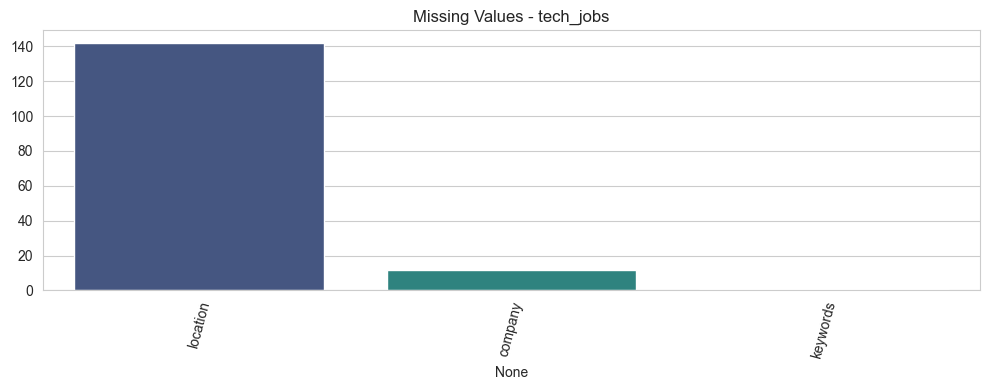

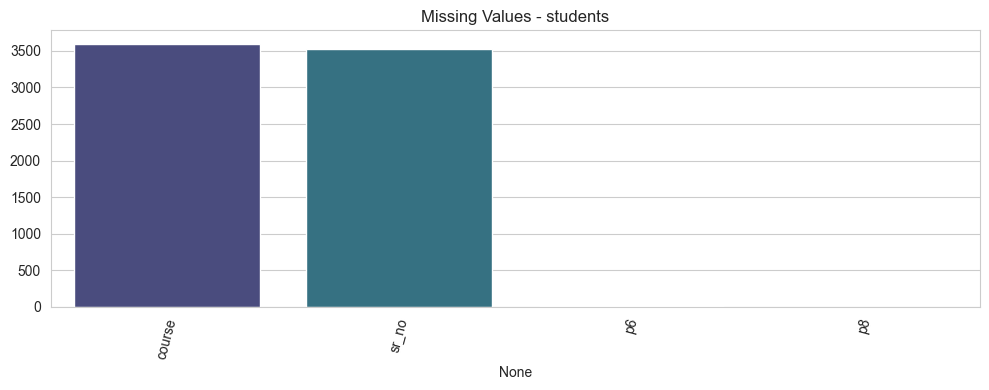

In [13]:
for name, df in [("tech_jobs", tech_jobs), ("job_market", job_market), ("students", students)]:
    na = df.isnull().sum().sort_values(ascending=False)
    na = na[na > 0]
    if len(na) > 0:
        plt.figure(figsize=(10, 4))
        sns.barplot(x=na.index, y=na.values, palette="viridis")
        plt.xticks(rotation=75)
        plt.title(f"Missing Values - {name}")
        plt.tight_layout()
        plt.show()

In [14]:
if "salary_usd" not in job_market.columns and "salary_usd" not in job_market.columns:
    if "salary_usd" not in job_market.columns and "salary_usd" not in job_market.columns:
        pass

salary_col_candidates = [c for c in job_market.columns if "salary" in c]
experience_col_candidates = [c for c in job_market.columns if "experience" in c]

print("Salary candidates:", salary_col_candidates)
print("Experience candidates:", experience_col_candidates)

Salary candidates: ['salary_usd']
Experience candidates: ['years_experience', 'experience_years']


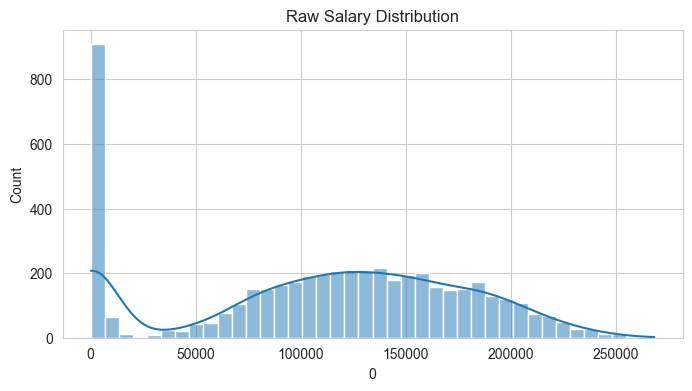

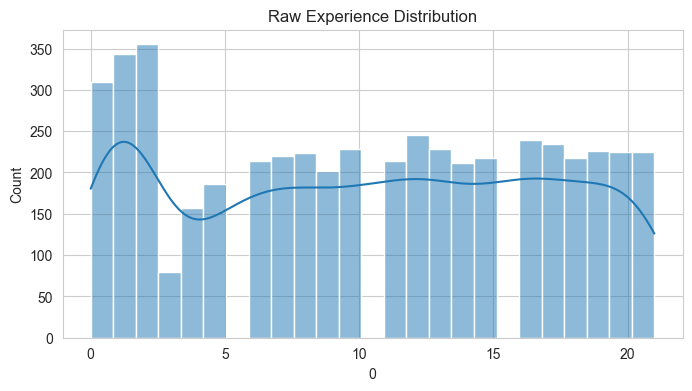

In [15]:
if len(salary_col_candidates) > 0:
    raw_salary_col = salary_col_candidates[0]
    plt.figure(figsize=(8, 4))
    job_market[raw_salary_col].astype(str).str.extract(r"(\d+\.?\d*)")[0].astype(float, errors="ignore")
    sns.histplot(pd.to_numeric(job_market[raw_salary_col].astype(str).str.extract(r"(\d+\.?\d*)")[0], errors="coerce"), bins=40, kde=True)
    plt.title("Raw Salary Distribution")
    plt.show()

if len(experience_col_candidates) > 0:
    raw_exp_col = experience_col_candidates[0]
    plt.figure(figsize=(8, 4))
    sns.histplot(pd.to_numeric(job_market[raw_exp_col].astype(str).str.extract(r"(\d+\.?\d*)")[0], errors="coerce"), bins=25, kde=True)
    plt.title("Raw Experience Distribution")
    plt.show()

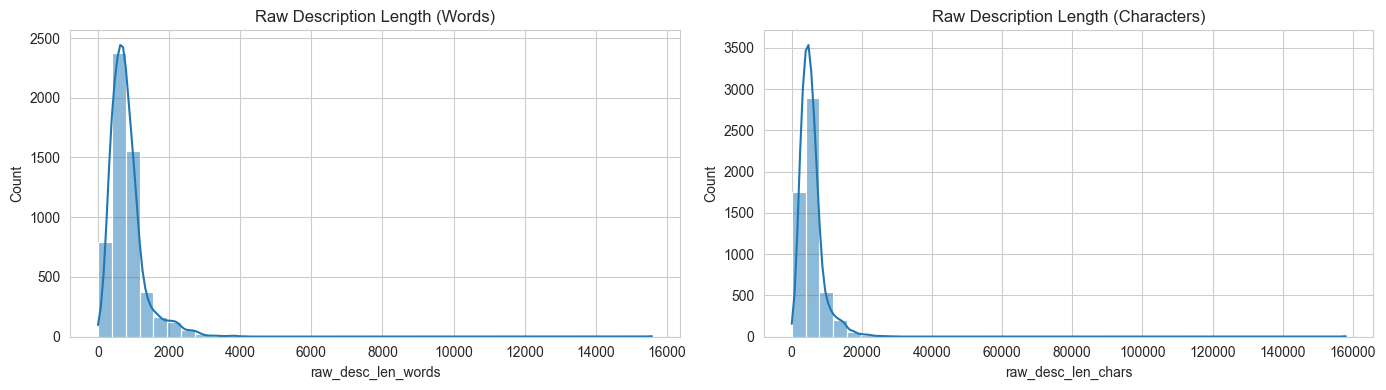

In [16]:
if "job_description" in tech_jobs.columns:
    tech_jobs["raw_desc_len_words"] = tech_jobs["job_description"].astype(str).apply(lambda x: len(x.split()))
    tech_jobs["raw_desc_len_chars"] = tech_jobs["job_description"].astype(str).apply(len)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(tech_jobs["raw_desc_len_words"], bins=40, kde=True, ax=axes[0])
    axes[0].set_title("Raw Description Length (Words)")
    sns.histplot(tech_jobs["raw_desc_len_chars"], bins=40, kde=True, ax=axes[1])
    axes[1].set_title("Raw Description Length (Characters)")
    plt.tight_layout()
    plt.show()

In [17]:
if "location" in tech_jobs.columns:
    display(tech_jobs["location"].astype(str).value_counts().head(10).to_frame("count"))

if "category" in tech_jobs.columns:
    display(tech_jobs["category"].astype(str).value_counts().head(10).to_frame("count"))

profession_cols = [c for c in students.columns if "profession" in c]
if profession_cols:
    display(students[profession_cols[0]].astype(str).value_counts().head(10).to_frame("count"))

,count
location,
Remote,1608
Full-time,388
Full-Time,289
Full Time,264
nan,142
Employee,74
Washington,62
New York,52
Full time,44


,count
category,
Other,1502
Management,961
Backend,599
Data,596
Sales,554
Support,447
Full Stack,245
DevOps,226
PM,192


,count
job_profession,
Astronomer\n,50
Geologist,50
Marine Biologist\n,50
Veterinarian,50
Nature photographer,50
Recording engineer,50
Audiologist,50
Sound editor,50
Music teacher,50


#### 5. Salary and Experience Cleaning
Convert salary and experience fields to usable numeric features and handle outliers.

In [18]:
salary_col_candidates = [c for c in job_market.columns if "salary" in c]
experience_col_candidates = [c for c in job_market.columns if "experience" in c]

salary_col = salary_col_candidates[0] if salary_col_candidates else None
exp_col = experience_col_candidates[0] if experience_col_candidates else None

if salary_col:
    job_market["salary_usd"] = job_market[salary_col].apply(parse_salary)
    job_market["salary_usd"] = clip_outliers_iqr(job_market["salary_usd"].dropna()).reindex(job_market.index)

if exp_col:
    job_market["experience_years"] = job_market[exp_col].apply(parse_experience)
    job_market["experience_years"] = job_market["experience_years"].fillna(job_market["experience_years"].median())
    

print(job_market[[col for col in ["salary_usd", "experience_years"] if col in job_market.columns]].head())

   salary_usd  experience_years
0    101507.0              11.0
1    142205.0               4.0
2         0.0               2.0
3    104064.0              18.0
4     73990.0               6.0


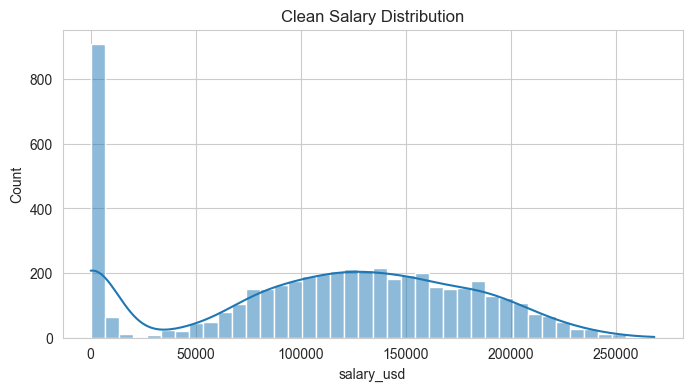

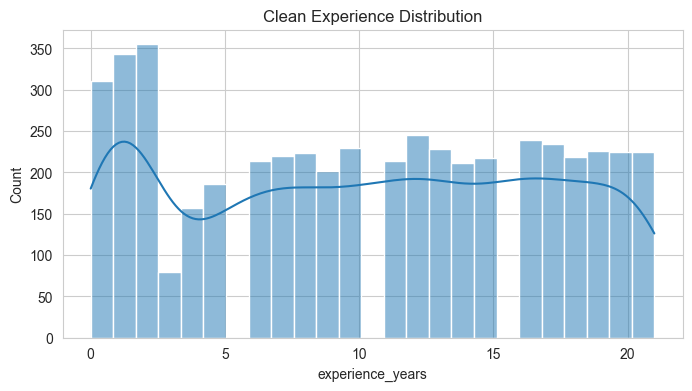

In [19]:
plt.figure(figsize=(8, 4))
sns.histplot(job_market["salary_usd"].dropna(), bins=40, kde=True)
plt.title("Clean Salary Distribution")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(job_market["experience_years"].dropna(), bins=25, kde=True)
plt.title("Clean Experience Distribution")
plt.show()

#### 6. Job Text Cleaning and Skill Extraction
Create a cleaned description column and extract standardized skills from job descriptions.

In [20]:
SKILL_DICT = {
    "python": ["python"],
    "sql": ["sql", "mysql", "postgresql", "postgres"],
    "excel": ["excel", "spreadsheet"],
    "power bi": ["power bi", "powerbi"],
    "tableau": ["tableau"],
    "r": [" r ", "r language"],
    "machine learning": ["machine learning", "ml"],
    "deep learning": ["deep learning"],
    "nlp": ["nlp", "natural language processing"],
    "aws": ["aws", "amazon web services"],
    "azure": ["azure", "microsoft azure"],
    "gcp": ["gcp", "google cloud"],
    "spark": ["spark", "apache spark"],
    "hadoop": ["hadoop"],
    "git": ["git", "github", "gitlab"],
    "docker": ["docker"],
    "linux": ["linux", "unix"],
    "statistics": ["statistics", "statistical analysis"],
    "communication": ["communication", "presentation", "stakeholder communication"],
    "leadership": ["leadership", "team management"],
    "problem solving": ["problem solving", "analytical thinking"],
    "prompt engineering": ["prompt engineering", "llm prompting", "generative ai", "genai"]
}

In [21]:
def extract_skills(text, skill_dict=SKILL_DICT):
    text = f" {clean_text(text)} "
    found = []
    for canonical, patterns in skill_dict.items():
        for pattern in patterns:
            if f" {pattern} " in text or pattern in text:
                found.append(canonical)
                break
    return sorted(list(set(found)))

tech_jobs["job_description_clean"] = tech_jobs["job_description"].apply(clean_text) if "job_description" in tech_jobs.columns else ""
tech_jobs["skills"] = tech_jobs["job_description_clean"].apply(extract_skills)
tech_jobs["num_skills"] = tech_jobs["skills"].apply(len)

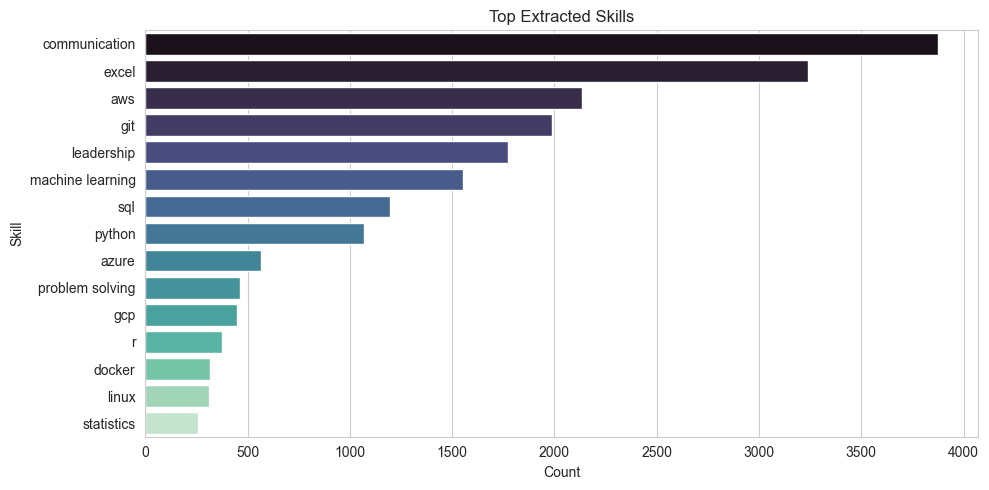

,job_description,job_description_clean,skills
0,"Oowlish Technology - Founding Engineer - AI/Python Cookie Policy 🍪 Deny Accept Privacy Notice This website uses cookies to improve your web experience. By clicking Accept , you agree to the use of...",oowlish technology - founding engineer - ai/python cookie policy deny accept privacy notice this website uses cookies to improve your web experience. by clicking accept you agree to the use of coo...,"[aws, communication, git, python]"
1,"Oneida Total Integrated Enterprises (OTIE) currently has an immediate opening for a Remote Senior Structural Engineer. We currently have a solid backlog of projects, an excellent staff of engineer...",oneida total integrated enterprises otie currently has an immediate opening for a remote senior structural engineer. we currently have a solid backlog of projects an excellent staff of engineers a...,"[aws, excel]"
2,Affinity Psychological Services is a rapidly-growing mental health group private practice that is diversity-affirming and committed to anti-burnout culture in everything we do. We nurture and cele...,affinity psychological services is a rapidly-growing mental health group private practice that is diversity-affirming and committed to anti-burnout culture in everything we do. we nurture and cele...,"[communication, leadership]"
3,Job Overview for Director of Children’s Ministry Do you love children and desire to nurture their faith in Christ? Do you have a pioneering spirit that embraces the challenge of developing a compr...,job overview for director of children s ministry do you love children and desire to nurture their faith in christ do you have a pioneering spirit that embraces the challenge of developing a compre...,[]
4,CDC Foundation - Data Engineer Data Engineer Ohio Program Innovation Office - Workforce Acceleration Initiative- Field Staff – Ohio- Cleveland- WAI / Full-Time / Remote Apply for this job The CDC ...,cdc foundation - data engineer data engineer ohio program innovation office - workforce acceleration initiative- field staff ohio- cleveland- wai / full-time / remote apply for this job the cdc fo...,"[aws, azure, python, r, sql]"
5,"OverviewWe are seeking a detail-oriented and organized Bookkeeper to join our team. The ideal candidate will be responsible for managing financial records, ensuring accuracy in accounts, and suppo...",overviewwe are seeking a detail-oriented and organized bookkeeper to join our team. the ideal candidate will be responsible for managing financial records ensuring accuracy in accounts and support...,[excel]
6,"Oowlish Technology - Founding Engineer - AI/Python Cookie Policy 🍪 Deny Accept Privacy Notice This website uses cookies to improve your web experience. By clicking Accept , you agree to the use of...",oowlish technology - founding engineer - ai/python cookie policy deny accept privacy notice this website uses cookies to improve your web experience. by clicking accept you agree to the use of coo...,"[aws, communication, git, python]"
7,"Qualities Is fluent in English Can write, speak, and read fluently Ideal to have a background in hardware or electronics Ideal to be in a similar timezone Reliable work (8 hrs/day) Ideal to have a...",qualities is fluent in english can write speak and read fluently ideal to have a background in hardware or electronics ideal to be in a similar timezone reliable work 8 hrs/day ideal to have a mar...,[]
8,"GREENLIGHT ABA IS LOOKING FOR A BCBA TO WORK REMOTELY IN ARIZONA. GENEROUS BONUS OPPORTUNITIES! MUST HAVE A CURRENT ARIZONA LBA! Flexible Schedule, Work-Life Balance, Listen to Staff Ideas, Bonus ...",greenlight aba is looking for a bcba to work remotely in arizona. generous bonus opportunities must have a current arizona lba flexible schedule work-life balance listen to staff ideas bonus oppor...,"[communication, excel]"
9,"Oowlish Technology - Founding Engineer - AI/Python Cookie Policy 🍪 Deny Accept Privacy Notice This website uses cookies to improve you

In [22]:
all_skills = [skill for row in tech_jobs["skills"] for skill in row]
skill_counts = pd.Series(Counter(all_skills)).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=skill_counts.head(15).values, y=skill_counts.head(15).index, palette="mako")
plt.title("Top Extracted Skills")
plt.xlabel("Count")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

display(tech_jobs[["job_description", "job_description_clean", "skills"]].head(10))

#### 7. Student Data Preparation
Clean student profiles, standardize target profession names, and create unique student identifiers.

In [23]:
students = students.copy()

if "sr_no" in students.columns:
    students = students.drop(columns=["sr_no"], errors="ignore")

students["student_id"] = [f"student_{i}" for i in range(len(students))]

profession_col = None
for c in students.columns:
    if "job_profession" in c or "profession" in c:
        profession_col = c
        break

if profession_col:
    students["target_profession"] = students[profession_col].astype(str).str.strip().str.lower()

score_cols = [c for c in students.columns if c not in ["student_id", "target_profession", profession_col]]
for c in score_cols:
    students[c] = pd.to_numeric(students[c], errors="ignore")

In [24]:
display(students.head())
if "target_profession" in students.columns:
    display(students["target_profession"].value_counts().head(15).to_frame("count"))

,course,job_profession,student,linguistic,musical,bodily,logical_mathematical,spatial_visualization,interpersonal,intrapersonal,naturalist,s_p,p1,p2,p3,p4,p5,p6,p7,p8,student_id,target_profession
0,NaN,Astronomer\n,S1,11,5,12,16,17,11,18,19,s1,AVG,POOR,AVG,BEST,BEST,AVG,BEST,BEST,student_0,astronomer
1,NaN,Astronomer\n,S2,12,6,12,16,16,11,18,19,s2,AVG,POOR,AVG,BEST,BEST,AVG,BEST,BEST,student_1,astronomer
2,NaN,Astronomer\n,S3,13,7,12,16,15,11,18,19,s3,AVG,POOR,AVG,BEST,BEST,AVG,BEST,BEST,student_2,astronomer
3,NaN,Astronomer\n,S4,14,8,12,16,19,11,18,19,s4,AVG,POOR,AVG,BEST,BEST,AVG,BEST,BEST,student_3,astronomer
4,NaN,Astronomer\n,S5,13,9,12,16,20,11,19,19,s5,AVG,POOR,AVG,BEST,BEST,AVG,BEST,BEST,student_4,astronomer


,count
target_profession,
astronomer,50
geologist,50
marine biologist,50
veterinarian,50
nature photographer,50
recording engineer,50
audiologist,50
sound editor,50
music teacher,50


#### 8. Canonical Job Fields
Prepare common fields such as job title, industry, location, region, and posting date.

In [25]:
tech_jobs["job_title"] = tech_jobs["category"].astype(str).str.strip().str.lower() if "category" in tech_jobs.columns else "unknown"
tech_jobs["industry"] = tech_jobs["company"].astype(str).str.strip().str.lower() if "company" in tech_jobs.columns else "unknown"
tech_jobs["location"] = tech_jobs["location"].astype(str).str.strip().str.lower() if "location" in tech_jobs.columns else "unknown"

if "date_posted" in tech_jobs.columns:
    tech_jobs["date_posted"] = pd.to_datetime(tech_jobs["date_posted"], errors="coerce")
    tech_jobs["posting_month"] = tech_jobs["date_posted"].dt.to_period("M").astype(str)
else:
    tech_jobs["posting_month"] = "unknown"

#### 9. Automation Risk Labeling
Create a rule-based automation risk score from job-description patterns and extracted skills.

In [26]:
HIGH_RISK_TERMS = [
    "data entry", "manual reporting", "routine reporting", "documentation",
    "invoice processing", "transcription", "scheduling", "clerical", "back office"
]

MEDIUM_RISK_TERMS = [
    "dashboard", "reporting", "excel automation", "sql queries", "quality assurance",
    "support", "monitoring", "operations"
]

LOW_RISK_TERMS = [
    "machine learning", "strategy", "stakeholder management", "experimentation",
    "forecasting", "ai governance", "decision making", "optimization", "modeling"
]

def automation_risk_score(text, skills):
    text = clean_text(text)
    score = 50
    
    for term in HIGH_RISK_TERMS:
        if term in text:
            score += 12
    for term in MEDIUM_RISK_TERMS:
        if term in text:
            score += 5
    for term in LOW_RISK_TERMS:
        if term in text:
            score -= 10

    advanced_skills = {"python", "machine learning", "nlp", "aws", "azure", "gcp", "statistics", "prompt engineering"}
    score -= 3 * len(set(skills).intersection(advanced_skills))
    score = max(0, min(100, score))
    return score

tech_jobs["automation_risk_score"] = tech_jobs.apply(
    lambda row: automation_risk_score(row.get("job_description_clean", ""), row.get("skills", [])),
    axis=1
)

def risk_label(score):
    if score >= 67:
        return "high"
    elif score >= 34:
        return "medium"
    return "low"

tech_jobs["automation_risk_label"] = tech_jobs["automation_risk_score"].apply(risk_label)

,job_title,skills,automation_risk_score,automation_risk_label
0,data,"[aws, communication, git, python]",44,medium
1,other,"[aws, excel]",52,medium
2,management,"[communication, leadership]",67,high
3,other,[],55,medium
4,data,"[aws, azure, python, r, sql]",63,medium
5,other,[excel],55,medium
6,backend,"[aws, communication, git, python]",44,medium
7,sales,[],55,medium
8,other,"[communication, excel]",55,medium
9,backend,"[aws, communication, git, python]",44,medium


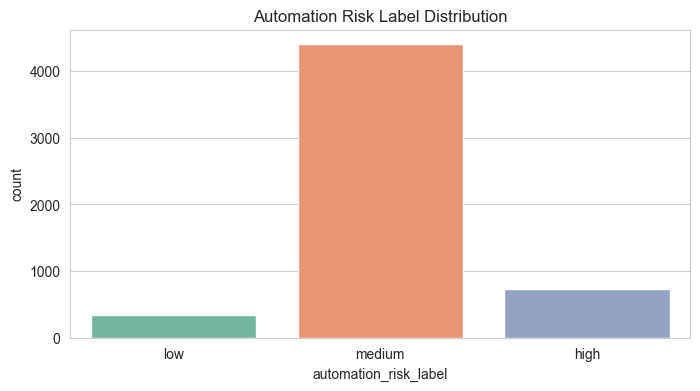

In [27]:
display(tech_jobs[["job_title", "skills", "automation_risk_score", "automation_risk_label"]].head(10))

plt.figure(figsize=(8, 4))
sns.countplot(data=tech_jobs, x="automation_risk_label", order=["low", "medium", "high"], palette="Set2")
plt.title("Automation Risk Label Distribution")
plt.show()

#### 10. Merge and Prepare Master Tables
Create job master and student profile outputs for downstream notebooks.

In [28]:
job_master = tech_jobs.copy()

if "current_role" in job_market.columns:
    role_salary = (
        job_market.groupby(job_market["current_role"].astype(str).str.lower())["salary_usd"]
        .median()
        .reset_index()
        .rename(columns={"current_role": "job_title", "salary_usd": "median_salary_usd"})
    )
    job_master = job_master.merge(role_salary, on="job_title", how="left")
else:
    job_master["median_salary_usd"] = np.nan

job_master["median_salary_usd"] = job_master["median_salary_usd"].fillna(job_master["median_salary_usd"].median())

In [29]:
job_master = job_master[
    [
        "job_title", "industry", "location", "posting_month",
        "job_description", "job_description_clean",
        "skills", "num_skills",
        "automation_risk_score", "automation_risk_label",
        "median_salary_usd"
    ]
].copy()

display(job_master.head())
print(job_master.shape)

,job_title,industry,location,posting_month,job_description,job_description_clean,skills,num_skills,automation_risk_score,automation_risk_label,median_salary_usd
0,data,oowlish technology,remote,2024-10,"Oowlish Technology - Founding Engineer - AI/Python Cookie Policy 🍪 Deny Accept Privacy Notice This website uses cookies to improve your web experience. By clicking Accept , you agree to the use of...",oowlish technology - founding engineer - ai/python cookie policy deny accept privacy notice this website uses cookies to improve your web experience. by clicking accept you agree to the use of coo...,"[aws, communication, git, python]",4,44,medium,NaN
1,other,oneida esc group,remote,2024-10,"Oneida Total Integrated Enterprises (OTIE) currently has an immediate opening for a Remote Senior Structural Engineer. We currently have a solid backlog of projects, an excellent staff of engineer...",oneida total integrated enterprises otie currently has an immediate opening for a remote senior structural engineer. we currently have a solid backlog of projects an excellent staff of engineers a...,"[aws, excel]",2,52,medium,NaN
2,management,affinity psychological services. p.c.,remote,2024-10,Affinity Psychological Services is a rapidly-growing mental health group private practice that is diversity-affirming and committed to anti-burnout culture in everything we do. We nurture and cele...,affinity psychological services is a rapidly-growing mental health group private practice that is diversity-affirming and committed to anti-burnout culture in everything we do. we nurture and cele...,"[communication, leadership]",2,67,high,NaN
3,other,the christian and missionary alliance - u.s. church ministries,remote,2024-10,Job Overview for Director of Children’s Ministry Do you love children and desire to nurture their faith in Christ? Do you have a pioneering spirit that embraces the challenge of developing a compr...,job overview for director of children s ministry do you love children and desire to nurture their faith in christ do you have a pioneering spirit that embraces the challenge of developing a compre...,[],0,55,medium,NaN
4,data,cdc foundation,full-time,2024-10,CDC Foundation - Data Engineer Data Engineer Ohio Program Innovation Office - Workforce Acceleration Initiative- Field Staff – Ohio- Cleveland- WAI / Full-Time / Remote Apply for this job The CDC ...,cdc foundation - data engineer data engineer ohio program innovation office - workforce acceleration initiative- field staff ohio- cleveland- wai / full-time / remote apply for this job the cdc fo...,"[aws, azure, python, r, sql]",5,63,medium,NaN


(5466, 11)


#### 11. After-Cleaning Validation
Check missing values, duplicate rows, top cleaned skills, and cleaned role/location quality.

In [30]:
print("JOB MASTER MISSING VALUES:\n", job_master.isnull().sum().sort_values(ascending=False))
# Check for duplicates excluding the 'skills' column
duplicates = job_master.drop(columns=["skills"]).duplicated().sum()
print("\nJOB MASTER DUPLICATES (excluding skills):", duplicates)

print("\nSTUDENTS MISSING VALUES:\n", students.isnull().sum().sort_values(ascending=False))
print("\nSTUDENTS DUPLICATES:", students.duplicated().sum())

JOB MASTER MISSING VALUES:
 median_salary_usd        5466
industry                    0
job_title                   0
location                    0
posting_month               0
job_description_clean       0
job_description             0
skills                      0
num_skills                  0
automation_risk_score       0
automation_risk_label       0
dtype: int64

JOB MASTER DUPLICATES (excluding skills): 42

STUDENTS MISSING VALUES:
 course                   3600
p6                          6
p8                          1
linguistic                  0
student                     0
job_profession              0
bodily                      0
musical                     0
logical_mathematical        0
spatial_visualization       0
naturalist                  0
s_p                         0
interpersonal               0
intrapersonal               0
p2                          0
p1                          0
p4                          0
p3                          0
p5              

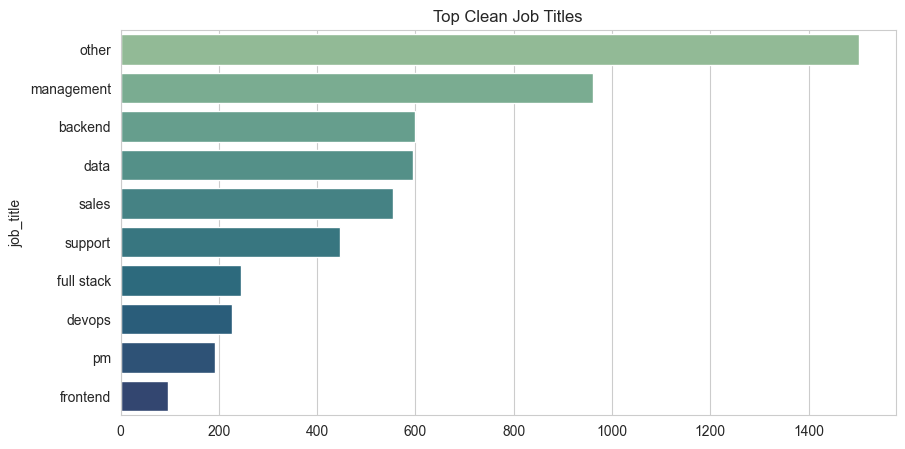

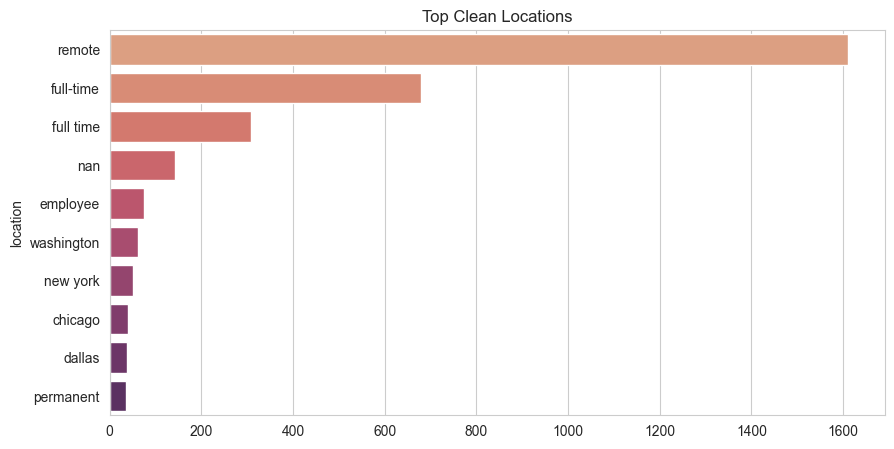

In [31]:
plt.figure(figsize=(10, 5))
sns.barplot(x=job_master["job_title"].value_counts().head(10).values,
            y=job_master["job_title"].value_counts().head(10).index,
            palette="crest")
plt.title("Top Clean Job Titles")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x=job_master["location"].value_counts().head(10).values,
            y=job_master["location"].value_counts().head(10).index,
            palette="flare")
plt.title("Top Clean Locations")
plt.show()

In [32]:
print("Job Titles in Master:", job_master["job_title"].unique()[:10])
print("Job Titles in Role Salary:", role_salary["job_title"].unique()[:10])

Job Titles in Master: ['data' 'other' 'management' 'backend' 'sales' 'support' 'full stack'
 'frontend' 'pm' 'devops']
Job Titles in Role Salary: ['data analyst' 'data scientist' 'ml engineer' 'researcher' 'student']


In [33]:
job_master["job_title"] = job_master["job_title"].str.strip().str.lower()
role_salary["job_title"] = role_salary["job_title"].str.strip().str.lower()

In [34]:
global_median = job_master["median_salary_usd"].median()
# If global median is also NaN, use a sensible default
if pd.isna(global_median):
    global_median = 60000 

job_master["median_salary_usd"] = job_master["median_salary_usd"].fillna(global_median)

In [35]:
# Check how many rows match
match_count = job_master.merge(role_salary, on="job_title", how="inner").shape[0]
print(f"Number of successfully merged rows: {match_count}")
print(f"Total rows in job_master: {len(job_master)}")

if match_count == 0:
    print("Warning: No job titles matched! Please check if your 'job_title' formatting is consistent.")

Number of successfully merged rows: 0
Total rows in job_master: 5466


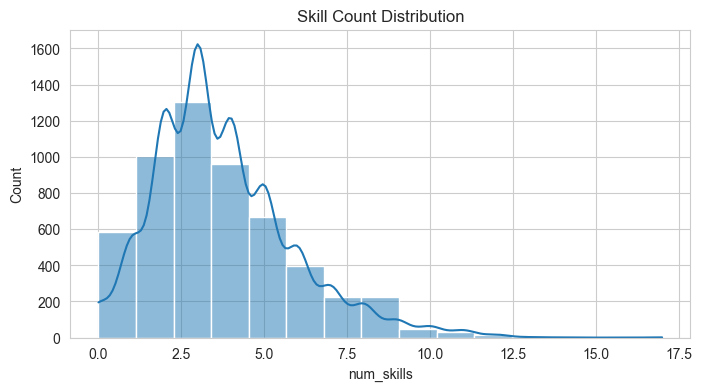

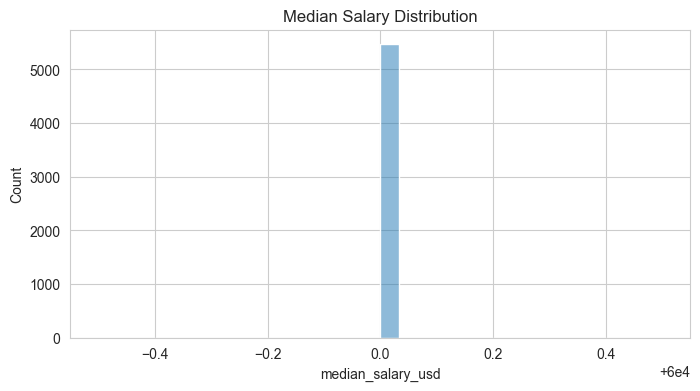

In [36]:
plt.figure(figsize=(8, 4))
sns.histplot(job_master["num_skills"], bins=15, kde=True)
plt.title("Skill Count Distribution")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(job_master["median_salary_usd"].dropna(), bins=30, kde=True)
plt.title("Median Salary Distribution")
plt.show()

#### 12. Export Cleaned Files
Save outputs for modeling and recommendation engine notebooks.

In [37]:
job_master.to_csv(OUTPUT_DIR / "jobs_master.csv", index=False)
students.to_csv(OUTPUT_DIR / "student_profiles.csv", index=False)
job_market.to_csv(OUTPUT_DIR / "clean_job_market.csv", index=False)
tech_jobs.to_csv(OUTPUT_DIR / "clean_tech_jobs.csv", index=False)

skill_dictionary_df = pd.DataFrame({
    "canonical_skill": list(SKILL_DICT.keys()),
    "aliases": [", ".join(v) for v in SKILL_DICT.values()]
})
skill_dictionary_df.to_csv(OUTPUT_DIR / "skill_dictionary.csv", index=False)

with open(OUTPUT_DIR / "skill_list.json", "w") as f:
    json.dump(list(SKILL_DICT.keys()), f, indent=2)

print("Files exported successfully to output/")

Files exported successfully to output/


#### 13. Final Output Summary
This notebook produced:
- cleaned job data
- cleaned student profiles
- extracted skill lists
- automation risk labels
- salary-ready and recommendation-ready master tables
